 1) Analyzing the glaciers-dataset from Switzerland & cleaning it

In [4]:
import pandas as pd

df = pd.read_csv('volumechange_glamos.csv', skiprows=2, header=0, dtype=str)
df = df.drop(index=0).reset_index(drop=True)

def parse_glacier_date(val):
    s = str(val).split('.')[0]
    if len(s) != 8 or not s.isdigit():
        return pd.NaT
    year  = s[:4]
    month = s[4:6] if s[4:6] not in ('99', '00') else '01'
    day   = s[6:8] if int(s[6:8]) <= 31 and s[6:8] != '00' else '01'
    try:
        return pd.Timestamp(f'{year}-{month}-{day}')
    except:
        return pd.NaT

for col in ['date_start', 'date_end']:
    df[col] = df[col].apply(parse_glacier_date)

numeric_cols = ['A_start', 'A_end', 'dV', 'dh_mean', 'Bgeod', 'sigma', 'covered', 'rho_dv']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
df['Name'] = df['Name'].str.strip()

print(df[df['date_start'].isna()])

Empty DataFrame
Columns: [SGI-ID, source_start, source_end, date_start, date_end, A_start, outline_start, A_end, outline_end, dV, dh_mean, Bgeod, sigma, covered, rho_dv, Name]
Index: []


In [5]:
# überblick verschaffen

print(df.shape)

(19017, 16)


In [6]:
print(df.dtypes)


SGI-ID                      str
source_start                str
source_end                  str
date_start       datetime64[us]
date_end         datetime64[us]
A_start                 float64
outline_start               str
A_end                   float64
outline_end                 str
dV                      float64
dh_mean                 float64
Bgeod                   float64
sigma                   float64
covered                 float64
rho_dv                    int64
Name                        str
dtype: object


In [10]:
print(df.isnull().sum())


SGI-ID           0
source_start     0
source_end       0
date_start       0
date_end         0
A_start          0
outline_start    0
A_end            0
outline_end      0
dV               0
dh_mean          0
Bgeod            0
sigma            0
covered          0
rho_dv           0
Name             0
dtype: int64


In [9]:
df.head()

,SGI-ID,source_start,source_end,date_start,date_end,A_start,outline_start,A_end,outline_end,dV,dh_mean,Bgeod,sigma,covered,rho_dv,Name
0,A10g-02,dhm25-l1,sa3d-2018,1991-01-01,2014-01-01,0.5900,1973,0.3075,2014,-0.010135,-17.140,-0.835,0.152,100.0,850,Seegletscher
1,A10g-02,dhm25-l1,ss3d-r2024,1991-01-01,2020-08-21,0.5900,1973,0.2073,2022,-0.012218,-20.691,-0.898,0.167,100.0,850,Seegletscher
2,A10g-02,dhm25-l1,sa3d-2022,1991-01-01,2021-01-01,0.5900,1973,0.2073,2022,-0.010129,-17.153,-0.720,0.123,100.0,850,Seegletscher
3,A10g-02,dhm25-l1,is-stand,1991-01-01,2022-07-15,0.5900,1973,0.2073,2022,-0.013612,-23.052,-0.936,0.167,100.0,850,Seegletscher
4,A10g-02,sa3d-2018,ss3d-r2024,2014-01-01,2020-08-21,0.3075,2014,0.2073,2022,-0.002082,-6.763,-1.146,0.201,100.0,850,Seegletscher


2) What is the meaning of the columns? 

In [11]:
# Wie viele einzigartige Gletscher gibt es?
print(df['SGI-ID'].nunique())

1438


In [10]:
# Wie viele Messungen pro Gletscher im Schnitt?
print(df.groupby('SGI-ID').size().describe())

count    1438.000000
mean       13.224618
std        15.240143
min         1.000000
25%         6.000000
50%         9.000000
75%        13.000000
max       205.000000
dtype: float64


In [32]:
# Welche source_end-Kombinationen gibt es?
print(df['source_end'].value_counts())

source_end
is-stand      7105
is-spez       5025
ss3d-r2024    3122
sa3d-2018     1273
sa3d-2019      860
ai-bw          514
sa3d-2022      500
sa3d-2020      328
sa3d-2021      118
dhm25-l1        84
ai-col          42
sk10            27
lk50             4
kp25             4
ueb-plan         4
lk25             4
kp10             2
sk25             1
Name: count, dtype: int64


In [8]:
# Nur dhm25-l1 → ss3d-r2024 Messungen
# df_long = df[(df['source_start'] == 'dhm25-l1') & (df['source_end'] == 'ss3d-r2024')].copy()

#print(df_long.shape)
#print(df_long['dV'].sum().round(4), 'km³ Gesamtverlust')
#print(df_long['dV'].describe())

(1036, 16)
-19.2975 km³ Gesamtverlust
count    1036.000000
mean       -0.018627
std         0.077631
min        -1.905004
25%        -0.010447
50%        -0.003244
75%        -0.001012
max         0.000293
Name: dV, dtype: float64


3) Visualize

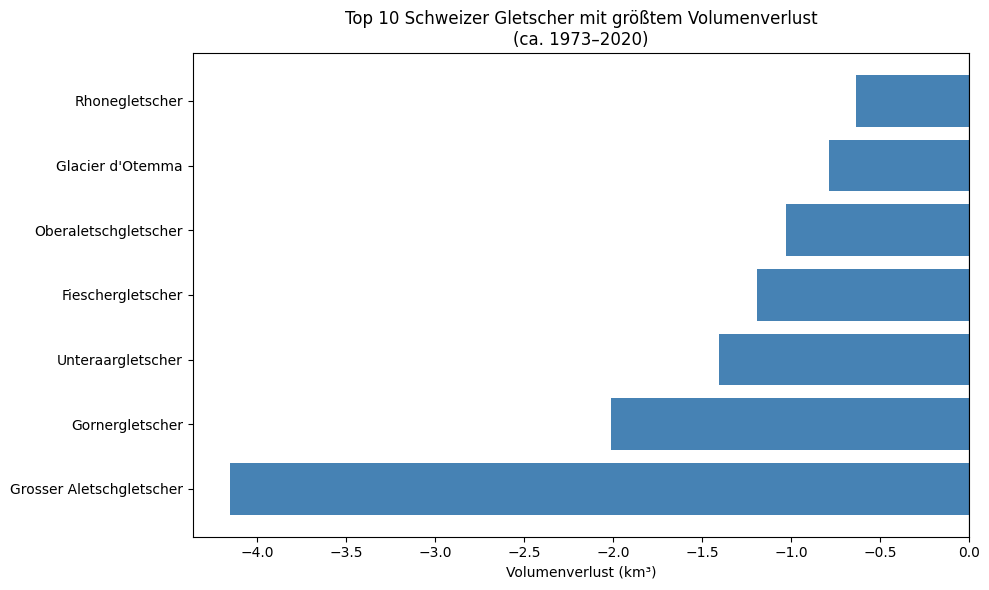

In [33]:
import matplotlib.pyplot as plt

top10 = df_long2.nsmallest(10, 'dV')[['Name', 'dV']].sort_values('dV')

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top10['Name'], top10['dV'], color='steelblue')
ax.set_xlabel('Volumenverlust (km³)')
ax.set_title('Top 10 Schweizer Gletscher mit größtem Volumenverlust\n(ca. 1973–2020)')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [34]:
# Verlust pro Jahr berechnen
df_long2['years'] = (df_long2['date_end'] - df_long2['date_start']).dt.days / 365.25
df_long2['dV_per_year'] = df_long2['dV'] / df_long2['years']
print(f"Durchschnittlicher Verlust pro Jahr: {df_long2['dV_per_year'].sum():.4f} km³/Jahr")

Durchschnittlicher Verlust pro Jahr: -1.2405 km³/Jahr


4) Koordinaten anschauen
   

In [35]:
glaciers = pd.read_csv(
    '/Users/aniellepeterhans/Lede/Data_Project2/glacier_list.csv',
    skiprows=8,
    names=['Name', 'SGI-ID', 'x_LV95', 'y_LV95', 'area', 'survey_year', 'length_change', 'mass_balance', 'volume_change']
)
glaciers = glaciers.drop(index=0).reset_index(drop=True)
glaciers['x_LV95'] = pd.to_numeric(glaciers['x_LV95'], errors='coerce')
glaciers['y_LV95'] = pd.to_numeric(glaciers['y_LV95'], errors='coerce')
print(glaciers.shape)   

(167, 9)


In [14]:
%pip install pyproj

Note: you may need to restart the kernel to use updated packages.


In [15]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [36]:
# Join
df_map = df_long2.merge(glaciers[['SGI-ID', 'Name', 'x_LV95', 'y_LV95']], on='SGI-ID', how='inner')
print(f"{len(df_map)} Gletscher gematcht")

# LV95 → WGS84 konvertieren
# pip install pyproj  (falls nicht installiert)
from pyproj import Transformer

transformer = Transformer.from_crs("EPSG:2056", "EPSG:4326", always_xy=True)
df_map['lon'], df_map['lat'] = transformer.transform(df_map['x_LV95'].values, df_map['y_LV95'].values)

print(df_map[['Name_x', 'lat', 'lon', 'dV']].head(5))

241 Gletscher gematcht
                  Name_x        lat       lon        dV
0          Jörigletscher  46.766010  9.966998 -0.007974
1      Scalettagletscher  46.695049  9.952541 -0.013144
2  Vadret da Porchabella  46.626974  9.882173 -0.065065
3         Vadret Üertsch  46.600011  9.842005 -0.001110
4           Vadret d'Err  46.545008  9.697012 -0.006804


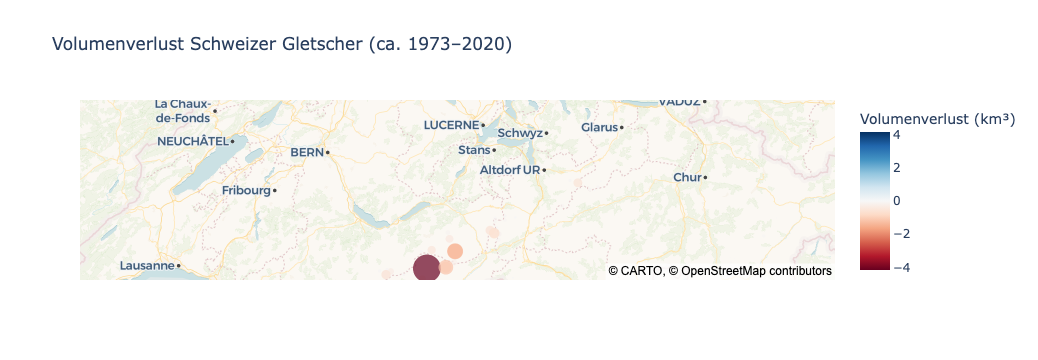

In [37]:
import plotly.express as px

fig = px.scatter_map(
    df_map,
    lat='lat',
    lon='lon',
    size=df_map['dV'].abs(),
    color='dV',
    hover_name='Name_x',
    hover_data={'dV': ':.4f', 'lat': False, 'lon': False},
    color_continuous_scale='RdBu',
    color_continuous_midpoint=0,
    zoom=7,
    center={'lat': 46.8, 'lon': 8.2},
    title='Volumenverlust Schweizer Gletscher (ca. 1973–2020)',
    labels={'dV': 'Volumenverlust (km³)'}
)

fig.show() ## doesnt work

In [44]:
#welche Gletscher haben am meisten Volumen verloren? 
df_long2.nsmallest(3, 'dV')[['Name', 'SGI-ID', 'dV', 'date_start', 'date_end']]

,Name,SGI-ID,dV,date_start,date_end
9970,Grosser Aletschgletscher,B36-26,-4.152703,1977-01-01,2023-08-23
13347,Gornergletscher,B56-07,-2.008365,1981-01-01,2023-08-23
5448,Unteraargletscher,A54g-11,-1.406427,1982-01-01,2023-08-23


In [46]:
#koordinaten für die 3 top gletscher
import geopandas as gpd
glaciers_shapes = gpd.read_file('/Users/aniellepeterhans/Lede/Data_Project2/inventory_sgi2016_r2020/SGI_2016_glaciers.shp')

In [48]:
top3_ids = ['B36-26', 'B56-07', 'A54g-11']
glaciers_shapes[glaciers_shapes['sgi-id'].isin(top3_ids)][['sgi-id', 'name', 'geometry']].to_crs('EPSG:4326').centroid

/var/folders/6l/pfxn447d4r108jw370zq5zr40000gn/T/ipykernel_33446/2097125517.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  glaciers_shapes[glaciers_shapes['sgi-id'].isin(top3_ids)][['sgi-id', 'name', 'geometry']].to_crs('EPSG:4326').centroid


599     POINT (8.01969 46.50348)
683      POINT (7.82396 45.9512)
1344    POINT (8.16277 46.56648)
dtype: geometry

In [49]:
%pip install folium

Note: you may need to restart the kernel to use updated packages.


In [50]:
import folium

m = folium.Map(location=[46.8, 8.2], zoom_start=8)

for _, row in df_map.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=abs(row['dV']) * 50,  # Größe proportional zum Verlust
        color='red',
        fill=True,
        fill_opacity=0.6,
        popup=f"{row['Name_x']}<br>dV: {row['dV']:.4f} km³"
    ).add_to(m)

m.save('glaciers_map.html')
print("Karte gespeichert als glaciers_map.html")

Karte gespeichert als glaciers_map.html


In [51]:
import json

features = []
for _, row in df_map.iterrows():
    features.append({
        "type": "Feature",
        "geometry": {
            "type": "Point",
            "coordinates": [row['lon'], row['lat']]
        },
        "properties": {
            "name": row['Name_x'],
            "dV": round(row['dV'], 6),
            "dV_abs": round(abs(row['dV']), 6),
            "SGI_ID": row['SGI-ID']
        }
    })

geojson = {"type": "FeatureCollection", "features": features}

with open('glaciers.geojson', 'w') as f:
    json.dump(geojson, f)

print(f"{len(features)} Gletscher exportiert")

241 Gletscher exportiert


In [52]:
%pip install geopandas

Note: you may need to restart the kernel to use updated packages.


In [53]:
import geopandas as gpd

glaciers_shapes = gpd.read_file('/Users/aniellepeterhans/Lede/Data_Project2/inventory_sgi2016_r2020/SGI_2016_glaciers.shp')
print(glaciers_shapes.shape)
print(glaciers_shapes.columns.tolist())
print(glaciers_shapes.head(3))

(1400, 20)
['gid', 'pk_glacier', 'sgi-id', 'name', 'rl_0', 'rl_1', 'rl_2', 'rl_3', 'i_code', 'year_acq', 'year_rel', 'area_km2', 'length_km', 'masl_min', 'masl_med', 'masl_mean', 'masl_max', 'slope_deg', 'aspect_deg', 'geometry']
       gid                            pk_glacier   sgi-id  \
0  16559.0  bb1e06de-74a9-11ea-bc55-0242ac130003  A10g-04   
1   1503.0  80f6be00-4ec8-11e8-85b0-985fd331b2ee  A54e-12   
2  17178.0  80e3ab30-4ec8-11e8-9357-985fd331b2ee  A54e-19   

                              name rl_0  rl_1  rl_2 rl_3 i_code  year_acq  \
0                              NaN    A     1     0    g     04      2014   
1                    Steigletscher    A     5     4    e     12      2016   
2  Vorder Tierberg (Innertkirchen)    A     5     4    e     19      2016   

   year_rel  area_km2  length_km  masl_min  masl_med  masl_mean  masl_max  \
0      2020  0.015169      0.234      3033      3101       3101      3168   
1      2020  5.561256      4.234      2032      2932       287

In [54]:
# Koordinaten nach WGS84 umwandeln
glaciers_shapes = glaciers_shapes.to_crs('EPSG:4326')

# Join mit Volumenverlust (df_long2)
glaciers_merged = glaciers_shapes.merge(
    df_long2[['SGI-ID', 'dV', 'dh_mean', 'date_start', 'date_end']],
    left_on='sgi-id',
    right_on='SGI-ID',
    how='left'
)

print(glaciers_merged['dV'].notna().sum(), 'Gletscher mit Volumendaten')

# Als GeoJSON exportieren
glaciers_merged[['sgi-id', 'name', 'area_km2', 'dV', 'dh_mean', 'geometry']].to_file(
    '/Users/aniellepeterhans/Lede/Data_Project2/glaciers_shapes.geojson',
    driver='GeoJSON'
)

print("Exportiert: glaciers_shapes.geojson")

1986 Gletscher mit Volumendaten
Exportiert: glaciers_shapes.geojson


In [56]:
# Fehlerbehebung: Alle Messungen für den Aletschgletscher anzeigen, der ist irgendwie nicht drin... 
df[df['Name'].str.contains('Aletsch', na=False)][['Name', 'SGI-ID', 'source_start', 'source_end', 'date_start', 'date_end', 'dV']]


,Name,SGI-ID,source_start,source_end,date_start,date_end,dV
9812,Kleines Aletschhorn,B36-13,dhm25-l1,sa3d-2018,1975-01-01,2011-01-01,-0.000263
9813,Kleines Aletschhorn,B36-13,dhm25-l1,sa3d-2019,1975-01-01,2016-01-01,-0.000279
9814,Kleines Aletschhorn,B36-13,dhm25-l1,is-stand,1975-01-01,2020-08-27,-0.000271
9815,Kleines Aletschhorn,B36-13,dhm25-l1,ss3d-r2024,1975-01-01,2021-08-21,-0.000266
9816,Kleines Aletschhorn,B36-13,dhm25-l1,is-stand,1975-01-01,2023-08-23,-0.000266
...,...,...,...,...,...,...,...
10090,Aletschhorn,B36-46,sa3d-2019,is-stand,2017-01-01,2020-08-27,-0.000278
10091,Aletschhorn,B36-46,sa3d-2019,ss3d-r2024,2017-01-01,2021-08-21,-0.000034
10092,Aletschhorn,B36-46,sa3d-2019,is-stand,2017-01-01,2023-08-23,-0.000317
10093,Aletschhorn,B36-46,is-stand,is-stand,2020-08-27,2023-08-23,-0.000092


In [57]:
df[df['Name'] == 'Grosser Aletschgletscher'][['source_start', 'source_end', 'date_start', 'date_end', 'dV']]

,source_start,source_end,date_start,date_end,dV
9950,kp25,kp25,1927-01-01,1957-09-01,-1.416615
9951,kp25,dhm25-l1,1927-01-01,1977-01-01,-1.865708
9952,kp25,ai-bw,1927-01-01,1980-09-18,-1.808282
9953,kp25,ai-bw,1927-01-01,1999-09-08,-3.140057
9954,kp25,sa3d-2018,1927-01-01,2008-01-01,-4.138658
9955,kp25,ai-bw,1927-01-01,2009-09-08,-4.222310
9956,kp25,sa3d-2019,1927-01-01,2017-01-01,-5.241183
9957,kp25,is-stand,1927-01-01,2023-08-23,-6.145109
9958,kp25,dhm25-l1,1957-09-01,1977-01-01,-0.313858
9959,kp25,ai-bw,1957-09-01,1980-09-18,-0.463699


In [31]:
df_long2 = df[(df['source_start'] == 'dhm25-l1') & (df['source_end'] == 'is-stand')].copy()
print(df_long2.shape)
print(df_long2.nsmallest(5, 'dV')[['Name', 'dV', 'date_start', 'date_end']])

(1998, 16)
                           Name        dV date_start   date_end
9970   Grosser Aletschgletscher -4.152703 1977-01-01 2023-08-23
13347           Gornergletscher -2.008365 1981-01-01 2023-08-23
5448          Unteraargletscher -1.406427 1982-01-01 2023-08-23
5447          Unteraargletscher -1.255162 1982-01-01 2021-08-12
10284         Fieschergletscher -1.192510 1962-01-01 2023-08-23


In [ ]:
# alles oben erstetzen mit df_long2